# Red Hospitalaria — Análisis de Red y Trayectorias

Análisis del grafo de traslados entre hospitales de la Red Sudeste.
Incluye: mapa de la red, métricas (betweenness, SSR), flujos frecuentes y evolución temporal.


In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("..")  # para importar desde /scripts

from scripts import bases, init_notebook as init


In [2]:
# Cargar todos los datos del proyecto en una sola línea
ctx = init.init_notebook(data_path="../data")

df_pacientes   = ctx["df_pacientes"]
traslados      = ctx["traslados"]
hosp_coords    = ctx["hosp_coords"]
municipios     = ctx["municipios"]
municipios_amba = ctx["municipios_amba"]


Cargando datos de pacientes...
[reconstruir_traslados] Se descartaron 82 traslados con error grave de fechas.
  → 29,696 registros | 27,294 pacientes únicos
  → 1,681 traslados reconstruidos
Cargando datos geográficos...
  → 15 hospitales con coordenadas
  → 9 municipios AMBA cargados

✓ Entorno listo.

--- CHEQUEO POST-LIMPIEZA ---
Filas:              29696
Pacientes únicos:   27294
Hospitales únicos:  15
Valores nulos (Fecha inicio): 3168
Valores nulos (Fecha egreso): 4023

Distribución tipo_egreso:
tipo_egreso
alta           17519
traslado        5330
otro            3580
muerte          2791
desconocido      476
Name: count, dtype: int64

Distribución evolución:
evolucion
 0    27147
-1     1392
 1      944
-2      200
 2       13
Name: count, dtype: int64


In [7]:
df_pacientes['tipo_egreso'].unique()

<StringArray>
['desconocido', 'alta', 'otro', 'traslado', 'muerte']
Length: 5, dtype: str

In [5]:
traslados

,Id Hospital,Nombre Hospital,Id,Fecha inicio,Estado al ingreso,Tipo al ingreso,Último estado,Último tipo,Sexo,Edad,...,nivel_ingreso,nivel_final,evolucion,Hospital siguiente,Fecha ingreso siguiente,dias_entre_hospitales,es_traslado,error_fecha,posible_interno,gravedad_error
24049,145,UPA 5 AB,AA31,2022-04-22 12:11:25,ocupadas_otros,intermedias,ocupadas_otros,intermedias,masculino,56.0,...,2,2,0,MODULO HOSPITALARIO 9 AB,2022-04-23 12:11:21,-1.0,True,True,True,1
24252,145,UPA 5 AB,AA47,2022-06-05 12:11:25,ocupadas_otros,intermedias,ocupadas_otros,intermedias,femenino,47.0,...,2,2,0,MODULO HOSPITALARIO 9 AB,2022-06-08 12:11:21,-1.0,True,True,True,1
25122,146,UPA 11 FV,AB13,2020-08-07 12:11:26,sospechosos,intermedias,sospechosos,intermedias,masculino,56.0,...,2,2,0,MODULO HOSPITALARIO 11 FV,2020-08-10 12:11:10,-1.0,True,True,True,1
24592,145,UPA 5 AB,AB52,2022-08-24 12:11:25,ocupadas_otros,intermedias,ocupadas_otros,intermedias,masculino,63.0,...,2,2,0,MODULO HOSPITALARIO 9 AB,2022-08-25 12:11:21,-1.0,True,True,True,1
24594,145,UPA 5 AB,AB52,2022-08-25 12:11:25,ocupadas_otros,intermedias,ocupadas_otros,intermedias,masculino,63.0,...,2,2,0,MODULO HOSPITALARIO 9 AB,2022-08-29 12:11:21,3.0,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1741,2,MI PUEBLO,ZY69,2020-07-17 12:11:08,sospechosos,intermedias,sospechosos,intermedias,femenino,48.0,...,2,2,0,MODULO HOSPITALARIO 11 FV,2020-07-18 12:11:10,0.0,True,False,False,0
25614,146,UPA 11 FV,ZZ37,2021-04-15 12:11:26,ocupadas_covid,intermedias,ocupadas_covid,intermedias,masculino,62.0,...,2,2,0,MODULO HOSPITALARIO 11 FV,2021-04-17 12:11:10,-1.0,True,True,True,1
25659,146,UPA 11 FV,ZZ63,2021-04-24 12:11:26,ocupadas_covid,intermedias,ocupadas_covid,intermedias,femenino,54.0,...,2,2,0,MODULO HOSPITALARIO 11 FV,2021-04-25 12:11:10,-1.0,True,True,True,1
25855,146,UPA 11 FV,ZZ79,2021-06-10 12:11:26,sospechosos,intermedias,ocupadas_covid,intermedias,femenino,59.0,...,2,2,0,MODULO HOSPITALARIO 11 FV,2021-06-12 12:11:10,-1.0,True,True,True,1


## 1. Funcionamiento de la Red General (AMBA)

### 1.1 Mapa con los hospitales y sus municipios alrededor

In [3]:
# Generar red
G, edges, fig_tuple = bases.analizar_red_hospitalaria(
    traslados, hosp_coords, 
    peso_minimo=1, 
    modo="estatico", 
    mostrar_resumen=True, 
    graficar=False
)

# Convertir red y nodos a GeoDataFrames con curvas
gdf_edges, gdf_nodes = bases.gdf_red_hospitalaria_curva(G, hosp_coords, curva_base=0.3)

# Graficar sobre AMBA
bases.plot_red_sobre_amba(gdf_edges, gdf_nodes, municipios_amba, mostrar_nombres=True, mostrar_peso=False)

Registros luego de filtros: 1681
Hospitales origen únicos: 13
Hospitales destino únicos: 13
Nodos en red: 14
Aristas en red: 49


AttributeError: module 'scripts.bases' has no attribute 'gdf_red_hospitalaria_curva'

In [ ]:
#### direccionar
#### cuurvadas
#### elegir sistema para los upas

### 1.2 Total de traslados

In [ ]:
# Resumen de traslados
res_tras = bases.resumen_traslados(traslados, imprimir=True)

Total de traslados: 1763
Cantidad de hospitales únicos: 13


In [ ]:
traslados

,Id Hospital,Nombre Hospital,Id,Fecha inicio,Estado al ingreso,Tipo al ingreso,Último estado,Último tipo,Sexo,Edad,...,Pasó por Críticas,Pasó por Intermedias,Pasó por Generales,Duracion días,murio,Hospital siguiente,Fecha ingreso siguiente,dias_entre_hospitales,es_traslado,error_fecha
26566,147,UPA 17 QU,1,2020-05-01 12:11:27,ocupadas_otros,intermedias,ocupadas_otros,intermedias,masculino,36,...,no,si,no,94.0,False,ONATIVIA,2020-05-19 12:11:20,-77.0,True,True
14986,8,ONATIVIA,4,2020-05-31 12:11:19,ocupadas_covid,intermedias,ocupadas_covid,intermedias,femenino,17,...,no,si,no,11.0,False,UPA 17 QU,2020-06-08 12:11:27,-3.0,True,True
24049,145,UPA 5 AB,AA31,2022-04-22 12:11:25,ocupadas_otros,intermedias,ocupadas_otros,intermedias,masculino,56,...,no,si,no,1.0,False,MODULO HOSPITALARIO 9 AB,2022-04-23 12:11:21,-1.0,True,True
24252,145,UPA 5 AB,AA47,2022-06-05 12:11:25,ocupadas_otros,intermedias,ocupadas_otros,intermedias,femenino,47,...,no,si,no,3.0,False,MODULO HOSPITALARIO 9 AB,2022-06-08 12:11:21,-1.0,True,True
25122,146,UPA 11 FV,AB13,2020-08-07 12:11:26,sospechosos,intermedias,sospechosos,intermedias,masculino,56,...,no,si,no,3.0,False,MODULO HOSPITALARIO 11 FV,2020-08-10 12:11:10,-1.0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19894,9,MODULO HOSPITALARIO 9 AB,ZY87,2022-02-18 12:11:21,ocupadas_otros,criticas,ocupadas_otros,criticas,masculino,66,...,si,no,no,3.0,False,UPA 5 AB,2022-02-18 12:11:25,-3.0,True,True
25614,146,UPA 11 FV,ZZ37,2021-04-15 12:11:26,ocupadas_covid,intermedias,ocupadas_covid,intermedias,masculino,62,...,no,si,no,2.0,False,MODULO HOSPITALARIO 11 FV,2021-04-17 12:11:10,-1.0,True,True
25659,146,UPA 11 FV,ZZ63,2021-04-24 12:11:26,ocupadas_covid,intermedias,ocupadas_covid,intermedias,femenino,54,...,no,si,no,1.0,False,MODULO HOSPITALARIO 11 FV,2021-04-25 12:11:10,-1.0,True,True
25855,146,UPA 11 FV,ZZ79,2021-06-10 12:11:26,sospechosos,intermedias,ocupadas_covid,intermedias,femenino,59,...,no,si,no,2.0,False,MODULO HOSPITALARIO 11 FV,2021-06-12 12:11:10,-1.0,True,True


### 1.3 Cantidad de traslados en función del tiempo

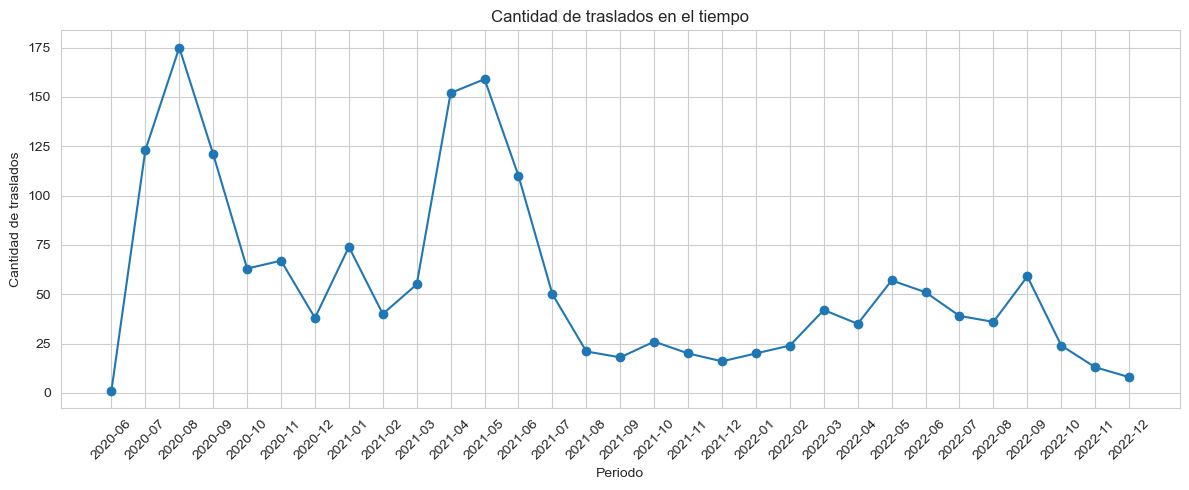

Fecha egreso
2020-06      1
2020-07    123
2020-08    175
2020-09    121
2020-10     63
2020-11     67
2020-12     38
2021-01     74
2021-02     40
2021-03     55
2021-04    152
2021-05    159
2021-06    110
2021-07     50
2021-08     21
2021-09     18
2021-10     26
2021-11     20
2021-12     16
2022-01     20
2022-02     24
2022-03     42
2022-04     35
2022-05     57
2022-06     51
2022-07     39
2022-08     36
2022-09     59
2022-10     24
2022-11     13
2022-12      8
dtype: int64

In [ ]:
bases.traslados_en_el_tiempo(traslados, freq="M")

### 1.4 Top de flujos entre hospitales (Caminos más frecuentes)

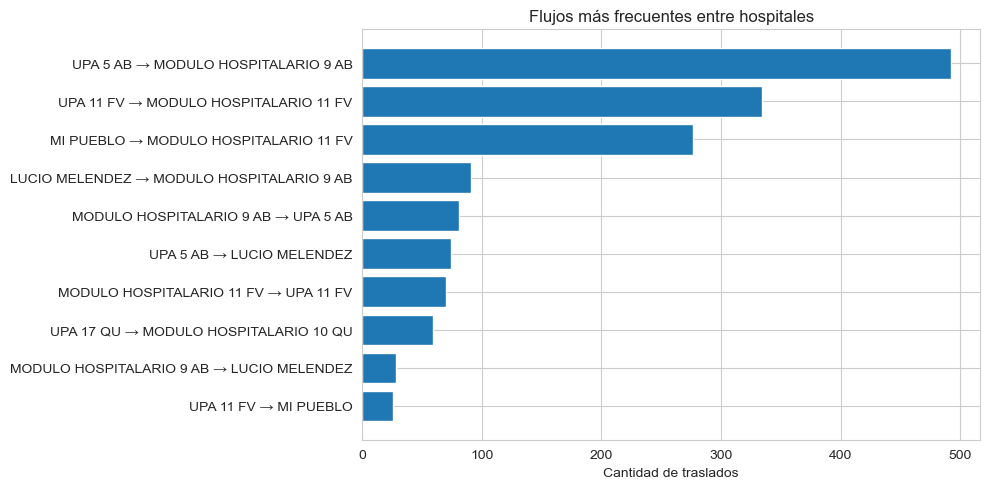

,Nombre Hospital,Hospital siguiente,cantidad
49,UPA 5 AB,MODULO HOSPITALARIO 9 AB,492
42,UPA 11 FV,MODULO HOSPITALARIO 11 FV,334
17,MI PUEBLO,MODULO HOSPITALARIO 11 FV,277
14,LUCIO MELENDEZ,MODULO HOSPITALARIO 9 AB,91
30,MODULO HOSPITALARIO 9 AB,UPA 5 AB,81
48,UPA 5 AB,LUCIO MELENDEZ,74
26,MODULO HOSPITALARIO 11 FV,UPA 11 FV,70
44,UPA 17 QU,MODULO HOSPITALARIO 10 QU,59
28,MODULO HOSPITALARIO 9 AB,LUCIO MELENDEZ,28
41,UPA 11 FV,MI PUEBLO,26


In [ ]:
bases.top_flujos_hospitales(traslados, top_n=10)

### 1.5 Métricas de la red (Grafos)

In [ ]:
bases.metricas_red(G, top_n=10)

Top hospitales por betweenness:
                     hospital  degree_centrality  betweenness  in_degree  \
0                    EL CRUCE           1.461538     0.481838        104   
12                   ONATIVIA           0.692308     0.226496          6   
10                  UPA 17 QU           0.538462     0.199786          7   
11                      OLLER           0.384615     0.193376          4   
6    MODULO HOSPITALARIO 9 AB           0.692308     0.122863        598   
4   MODULO HOSPITALARIO 10 QU           0.846154     0.057692         72   
3                   MI PUEBLO           0.538462     0.042735         40   
5   MODULO HOSPITALARIO 11 FV           0.461538     0.000000        618   
1                     IRIARTE           0.461538     0.000000         18   
2              LUCIO MELENDEZ           0.461538     0.000000        103   

    out_degree  
0           22  
12          31  
10          63  
11           3  
6          114  
4           39  
3          3

,hospital,degree_centrality,betweenness,in_degree,out_degree
0,EL CRUCE,1.461538,0.481838,104,22
12,ONATIVIA,0.692308,0.226496,6,31
10,UPA 17 QU,0.538462,0.199786,7,63
11,OLLER,0.384615,0.193376,4,3
6,MODULO HOSPITALARIO 9 AB,0.692308,0.122863,598,114
4,MODULO HOSPITALARIO 10 QU,0.846154,0.057692,72,39
3,MI PUEBLO,0.538462,0.042735,40,302
5,MODULO HOSPITALARIO 11 FV,0.461538,0.000000,618,101
1,IRIARTE,0.461538,0.000000,18,18
2,LUCIO MELENDEZ,0.461538,0.000000,103,118


In [ ]:
### Quizas poner par a par
# pagerank